# CatBoost

CatBoost is a gradient boosting algorithm developed by Yandex.

It is particularly powerful when working with datasets containing categorical features.

CatBoost can automatically handle categorical variables without requiring traditional preprocessing techniques such as one-hot encoding.

The name CatBoost comes from:

Categorical + Boosting

CatBoost is based on gradient boosting over decision trees.

## Why CatBoost?

Traditional machine learning models usually require categorical variables to be converted into numerical representations.

For example:

City:

Kolkata
Delhi
Mumbai

A common solution is One-Hot Encoding:

Kolkata -> [1, 0, 0]
Delhi   -> [0, 1, 0]
Mumbai  -> [0, 0, 1]

This can become inefficient when a categorical feature contains many unique categories.

CatBoost provides native support for categorical features.

Important advantages include:

- Native categorical feature handling
- Reduced need for manual preprocessing
- Ordered target statistics
- Ordered boosting
- Strong performance on tabular datasets
- Good default hyperparameters
- Built-in handling of missing values
- Support for classification and regression
- Feature importance
- Early stopping

## What is CatBoost?

CatBoost is an ensemble learning algorithm based on gradient boosting.

It builds many decision trees sequentially.

Each new tree attempts to correct the errors made by the previous trees.

The general idea is:
```
Initial Model
      ↓
Calculate Errors
      ↓
Build New Tree
      ↓
Update Model
      ↓
Calculate New Errors
      ↓
Build Another Tree
      ↓
...
      ↓
Final CatBoost Model
```
CatBoost differs from traditional gradient boosting mainly in how it handles categorical features and reduces target leakage during categorical encoding.

## CatBoost vs Other Boosting Algorithms

Three popular gradient boosting implementations are:

1. XGBoost
2. LightGBM
3. CatBoost

XGBoost:

- Powerful gradient boosting implementation
- Excellent performance on structured data
- Requires explicit preprocessing of categorical variables in many workflows

LightGBM:

- Very fast
- Efficient for large datasets
- Uses histogram-based learning
- Can handle large feature spaces efficiently

CatBoost:

- Excellent categorical feature support
- Requires less preprocessing
- Uses ordered boosting
- Often performs very well on mixed numerical + categorical datasets

There is no universally best boosting algorithm.

The correct choice depends on:

- Dataset size
- Feature types
- Computational resources
- Required training speed
- Model accuracy
- Interpretability requirements

## Key Ideas Behind CatBoost

## Ordered Target Statistics

Categorical features cannot directly be used by ordinary numerical decision trees.

A simple approach is to replace each category with its average target value.

For example:

City       Target
Kolkata       1
Kolkata       0
Delhi         1
Delhi         1

The mean target for Kolkata is:

mean(Kolkata) = (1 + 0) / 2 = 0.5

The mean target for Delhi is:

mean(Delhi) = (1 + 1) / 2 = 1.0

However, directly calculating target statistics using the complete training dataset can introduce target leakage.

CatBoost uses an ordered approach to reduce this problem.

## Ordered Statistics: Intuition

Suppose observations are randomly ordered:

Observation 1
Observation 2
Observation 3
Observation 4
Observation 5

When calculating the encoded value for Observation 4, CatBoost uses information from earlier observations rather than directly using the target value of Observation 4.

Conceptually:

Previous observations
        ↓
Calculate statistics
        ↓
Encode current observation

This prevents the current target from directly influencing its own feature representation.

The ordering is one of the important ideas behind CatBoost.

## Ordered Boosting

Standard gradient boosting can suffer from a form of prediction shift caused by the difference between the data used to construct the model and the data used to evaluate predictions.

CatBoost introduces Ordered Boosting to reduce this problem.

The basic intuition is:

Traditional boosting:
```
Full training data
       ↓
Calculate residuals
       ↓
Train next tree

CatBoost:

Ordered subsets / permutations
       ↓
Calculate statistics without using future targets
       ↓
Train next tree
```
This makes the training procedure more resistant to target leakage and prediction shift.

## CatBoost Architecture

CatBoost is an additive tree ensemble.

The prediction can be represented conceptually as:

Final Prediction =
Tree 1
+ Tree 2
+ Tree 3
+ ...
+ Tree M

Each tree contributes a small correction to the current model.

The model is gradually improved through gradient-based optimization.

## Mathematical Form

For a model containing M trees:

```text
F_M(x) = F_0(x) + η Σ h_m(x)

where:

F_0(x) = initial prediction

h_m(x) = prediction produced by tree m

η = learning rate

M = number of trees

The learning rate controls how strongly each tree contributes to the final model.

## Gradient Boosting Objective

CatBoost minimizes an objective function using gradient-based optimization.

```text
For a dataset containing n observations:

L = Σ L(y_i, F(x_i))

where:

y_i = actual target

F(x_i) = model prediction

L = loss function

The next tree is trained to approximate the negative gradient of the loss with respect to the current predictions.

Conceptually:

Current Model
      ↓
Calculate Loss
      ↓
Calculate Gradients
      ↓
Fit Tree to Gradients
      ↓
Update Model

## Install CatBoost

In [2]:
!python -m pip install catboost


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier, CatBoostRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

## Classification Example

We'll first use the Breast Cancer dataset to understand the basic CatBoost workflow.

In [4]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (455, 30)
Testing shape: (114, 30)


## Creating the Model

CatBoostClassifier is used when the target variable is categorical.

Important parameters:

iterations:
Number of boosting rounds.

learning_rate:
Controls the contribution of each tree.

depth:
Maximum depth of individual trees.

loss_function:
Loss optimized during training.

verbose:
Controls training output.

In [6]:
model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    verbose=50,
    random_seed=42
)

model.fit(X_train, y_train)

0:	learn: 0.6141452	total: 142ms	remaining: 42.4s
50:	learn: 0.0415349	total: 283ms	remaining: 1.38s
100:	learn: 0.0161972	total: 413ms	remaining: 814ms
150:	learn: 0.0089370	total: 542ms	remaining: 535ms
200:	learn: 0.0062872	total: 684ms	remaining: 337ms
250:	learn: 0.0053212	total: 830ms	remaining: 162ms
299:	learn: 0.0049437	total: 937ms	remaining: 0us


CatBoostClassifier(depth=6, iterations=300, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=50)

## Predictions

In [7]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [8]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.956140350877193
Precision: 0.9466666666666667
Recall   : 0.9861111111111112
F1 Score : 0.9659863945578231
ROC-AUC  : 0.996031746031746


## Classification Report

In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [10]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[38  4]
 [ 1 71]]


# CatBoost with Categorical Features

One of CatBoost's biggest advantages is its ability to work directly with categorical variables.

Consider a dataset:

    Age | City | Gender | Income | Purchased

    25 | Kolkata | Male | 40000 | 1
    32 | Delhi   | Female | 60000 | 0
    29 | Mumbai  | Male | 50000 | 1

City and Gender are categorical features.

Instead of manually applying One-Hot Encoding, CatBoost can receive these columns directly.

In [11]:
data = pd.DataFrame({
    "Age": [25, 32, 29, 41, 36, 27, 30, 45, 22, 34],
    "City": [
        "Kolkata", "Delhi", "Mumbai", "Kolkata", "Delhi",
        "Mumbai", "Kolkata", "Delhi", "Mumbai", "Kolkata"
    ],
    "Gender": [
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", "Male", "Female"
    ],
    "Income": [
        40000, 60000, 50000, 80000, 70000,
        45000, 52000, 90000, 35000, 65000
    ],
    "Purchased": [1, 0, 1, 1, 1, 0, 1, 1, 0, 0]
})

data

,Age,City,Gender,Income,Purchased
0,25,Kolkata,Male,40000,1
1,32,Delhi,Female,60000,0
2,29,Mumbai,Male,50000,1
3,41,Kolkata,Female,80000,1
4,36,Delhi,Male,70000,1
5,27,Mumbai,Female,45000,0
6,30,Kolkata,Male,52000,1
7,45,Delhi,Female,90000,1
8,22,Mumbai,Male,35000,0
9,34,Kolkata,Female,65000,0


In [12]:
X = data.drop("Purchased", axis=1)
y = data["Purchased"]

categorical_features = ["City", "Gender"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
cat_model = CatBoostClassifier(
    iterations=200,
    depth=5,
    learning_rate=0.05,
    loss_function="Logloss",
    verbose=False,
    random_seed=42
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

CatBoostClassifier(depth=5, iterations=200, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=False)

In [15]:
predictions = cat_model.predict(X_test)

print("Predictions:")
print(predictions)

Predictions:
[1 1]


# Important Hyperparameters

## iterations

Number of boosting iterations.

Higher values can increase model capacity but may increase overfitting and training time.

---

## learning_rate

Controls how much each tree contributes.

Small learning rate:

- More gradual learning
- Usually requires more iterations

Large learning rate:

- Faster learning
- Higher risk of overfitting

---

## depth

Controls tree depth.

Small depth:

- Simpler trees
- Lower computational cost
- Lower risk of overfitting

Large depth:

- More complex trees
- Can capture more interactions
- Higher risk of overfitting

---

## loss_function

Defines the optimization objective.

Examples:

Logloss
RMSE
MAE
MultiClass

---

## l2_leaf_reg

L2 regularization coefficient.

Increasing it can help control model complexity.

---

## random_strength

Controls randomness used during score calculation.

It can help reduce overfitting.

---

## border_count

Controls the number of splits used when quantizing numerical features.

---

## random_seed

Controls reproducibility.

---

## verbose

Controls how much training information is printed.

# Early Stopping

Training too many boosting iterations can cause overfitting.

CatBoost can monitor validation performance and stop training when the performance stops improving.

The idea is:

      Training Data
            ↓
      Train Tree
            ↓
      Validation Score improves?
            ↓
      Yes → Continue
      No  → Wait for patience period
            ↓
      Still no improvement?
            ↓
      Stop training

This is called Early Stopping.

In [16]:
# Reload the Breast Cancer dataset for a proper early stopping example

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

# Train + Test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train + Validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print("Training shape   :", X_train.shape)
print("Validation shape :", X_valid.shape)
print("Testing shape    :", X_test.shape)

Training shape   : (364, 30)
Validation shape : (91, 30)
Testing shape    : (114, 30)


In [17]:
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=50
)

0:	test: 0.9618163	best: 0.9618163 (0)	total: 3.55ms	remaining: 3.55s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9927760578
bestIteration = 16

Shrink model to first 17 iterations.


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=1000, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [18]:
print("Best iteration:", model.get_best_iteration())
print("Best score:", model.get_best_score())

Best iteration: 16
Best score: {'learn': {'Logloss': 0.02682474157312414}, 'validation': {'Logloss': 0.12122505665086075, 'AUC': 0.9927760577915377}}


# Feature Importance

Feature importance tells us how much each feature contributed to the model.

CatBoost provides built-in feature importance methods.

In [19]:
importance = model.get_feature_importance()

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
27,worst concave points,18.500894
23,worst area,15.707333
21,worst texture,8.386725
7,mean concave points,6.726564
22,worst perimeter,6.186567
20,worst radius,6.144903
10,radius error,4.748896
24,worst smoothness,4.253932
18,symmetry error,3.880282
6,mean concavity,3.243061


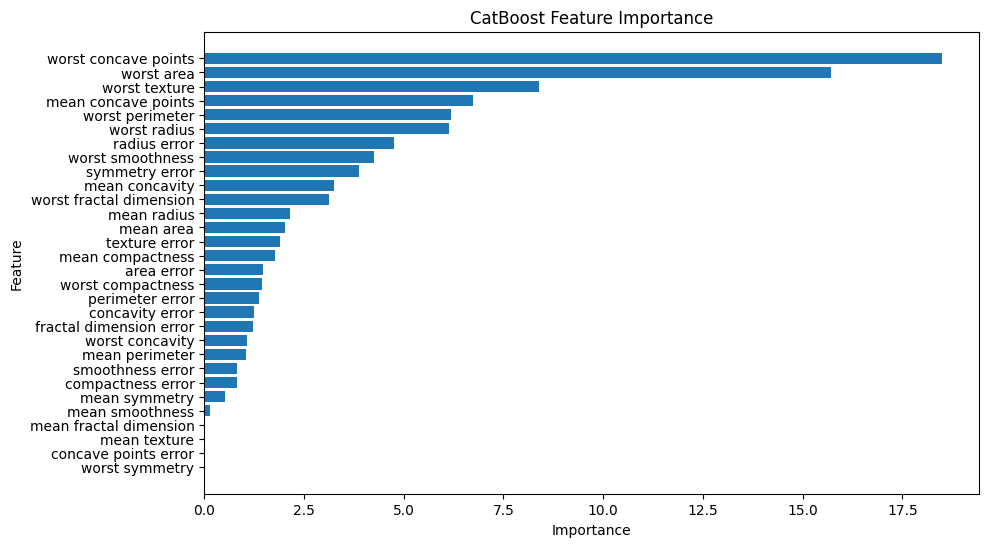

In [20]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("CatBoost Feature Importance")
plt.gca().invert_yaxis()

plt.show()

The most important features receive larger importance scores.

Feature importance can help us:

- Understand the model
- Identify useful variables
- Detect irrelevant variables
- Perform feature selection
- Explain model behavior

However, feature importance should not automatically be interpreted as causal importance.

# CatBoost Regression

CatBoost can also solve regression problems.
```
For regression:

Input Features
      ↓
CatBoost Regressor
      ↓
Continuous Prediction
```
Example:

Predict house prices.

In [26]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import pandas as pd

data = load_breast_cancer()

X_cb = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y_cb = pd.Series(
    data.target,
    name="target"
)

# Train + Test
X_cb_train_full, X_cb_test, y_cb_train_full, y_cb_test = train_test_split(
    X_cb,
    y_cb,
    test_size=0.2,
    random_state=42,
    stratify=y_cb
)

# Train + Validation
X_cb_train, X_cb_valid, y_cb_train, y_cb_valid = train_test_split(
    X_cb_train_full,
    y_cb_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_cb_train_full
)

print("Training shape   :", X_cb_train.shape)
print("Validation shape :", X_cb_valid.shape)
print("Testing shape    :", X_cb_test.shape)

Training shape   : (364, 30)
Validation shape : (91, 30)
Testing shape    : (114, 30)


# Simple Hyperparameter Experiment

Instead of performing an expensive hyperparameter search, we can manually test a few carefully selected configurations.

This approach is useful for learning because we can directly observe how hyperparameters affect model performance.

We will vary:

- depth
- learning_rate
- l2_leaf_reg

We keep the number of experiments small to reduce computation.

In [27]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

configs = [
    {
        "depth": 4,
        "learning_rate": 0.05,
        "l2_leaf_reg": 3
    },
    {
        "depth": 6,
        "learning_rate": 0.05,
        "l2_leaf_reg": 3
    },
    {
        "depth": 8,
        "learning_rate": 0.05,
        "l2_leaf_reg": 3
    },
    {
        "depth": 6,
        "learning_rate": 0.1,
        "l2_leaf_reg": 5
    }
]

results = []

for config in configs:

    model = CatBoostClassifier(
        iterations=300,
        depth=config["depth"],
        learning_rate=config["learning_rate"],
        l2_leaf_reg=config["l2_leaf_reg"],
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        thread_count=2,
        verbose=False
    )

    model.fit(
        X_cb_train,
        y_cb_train,
        eval_set=(X_cb_valid, y_cb_valid),
        early_stopping_rounds=30,
        verbose=False
    )

    y_valid_prob = model.predict_proba(X_cb_valid)[:, 1]

    auc = roc_auc_score(
        y_cb_valid,
        y_valid_prob
    )

    results.append({
        "depth": config["depth"],
        "learning_rate": config["learning_rate"],
        "l2_leaf_reg": config["l2_leaf_reg"],
        "best_iteration": model.get_best_iteration(),
        "validation_auc": auc
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    "validation_auc",
    ascending=False
)

,depth,learning_rate,l2_leaf_reg,best_iteration,validation_auc
1,6,0.05,3,16,0.992776
0,4,0.05,3,99,0.991744
3,6,0.10,5,7,0.991228
2,8,0.05,3,4,0.990712


# CatBoost vs XGBoost vs LightGBM

| Property | CatBoost | XGBoost | LightGBM |
|---|---|---|---|
| Boosting | Gradient Boosting | Gradient Boosting | Gradient Boosting |
| Categorical Features | Excellent | Usually requires preprocessing | Supports categorical features |
| Training Speed | Fast | Fast | Very Fast |
| Large Datasets | Good | Excellent | Excellent |
| Small/Medium Tabular Data | Excellent | Excellent | Excellent |
| Preprocessing | Often less | Usually more | Moderate |
| Ordered Boosting | Yes | No | No |
| Histogram Based | Yes | Yes | Yes |
| GPU Support | Yes | Yes | Yes |
| Interpretability | Moderate | Moderate | Moderate |

## Practical Rule

If your dataset contains many categorical variables:

CatBoost is often an excellent first model to try.

If you have a very large numerical dataset:

LightGBM can be particularly attractive.

If you want a highly configurable and mature gradient boosting framework:

XGBoost is an excellent choice.

In practice, benchmarking all three models is often better than assuming one will always win.

# Advantages of CatBoost

### 1. Excellent categorical feature handling

Categorical variables can often be passed directly to the model.

### 2. Reduced preprocessing

Less need for manual encoding.

### 3. Strong tabular performance

CatBoost is highly effective on structured datasets.

### 4. Ordered boosting

Helps reduce prediction shift and target leakage problems associated with naive target encoding.

### 5. Good default performance

CatBoost often performs well without extensive hyperparameter tuning.

### 6. Missing value handling

CatBoost can handle missing numerical values in many situations.

### 7. Feature importance

Built-in feature importance methods are available.

### 8. GPU support

CatBoost can utilize GPUs for suitable workloads.

### 9. Classification and regression

CatBoost supports multiple machine learning objectives.

# Disadvantages of CatBoost

### 1. Training can be slower than LightGBM

For some very large datasets, LightGBM may train faster.

### 2. Memory usage

Large datasets and high-cardinality categorical features can require substantial memory.

### 3. Model complexity

Like other boosting algorithms, CatBoost models can become difficult to interpret.

### 4. Hyperparameter sensitivity

Although CatBoost has strong defaults, tuning can still improve performance.

### 5. Not always the best model

There is no guarantee that CatBoost will outperform XGBoost or LightGBM on every dataset.

# When Should You Use CatBoost?

CatBoost is particularly attractive when:

- Dataset is tabular
- Dataset contains categorical features
- Categorical features have high cardinality
- You want to reduce preprocessing
- You need strong baseline performance
- You want built-in feature importance
- You want classification or regression
- You want to experiment with boosting models

Examples:

Customer churn prediction
Credit risk prediction
Fraud detection
Recommendation systems
Customer segmentation
Marketing prediction
Sales prediction
Price prediction
Ranking problems

# When Not to Use CatBoost

CatBoost may not be the ideal first choice when:

- Dataset is extremely large and training speed is the main concern
- Data is primarily unstructured
- Deep learning is more appropriate
- A simple linear model is sufficient
- Interpretability requirements are extremely strict

For image, audio, and raw text problems, specialized deep learning architectures are often more appropriate.

# Practical CatBoost Workflow

Real-world workflow:

1. Load dataset
2. Understand the data
3. Identify target variable
4. Separate X and y
5. Identify categorical features
6. Split data into train/validation/test
7. Build baseline CatBoost model
8. Evaluate baseline
9. Enable early stopping
10. Inspect feature importance
11. Tune hyperparameters
12. Evaluate on test set
13. Compare against other models
14. Save the final model
15. Deploy the model

The important principle is:

Do not immediately start hyperparameter tuning.

First establish a reliable baseline.

# Common Mistakes

### Mistake 1: Encoding categorical variables unnecessarily

One of CatBoost's major strengths is native categorical feature handling.

### Mistake 2: Passing categorical columns incorrectly

Make sure CatBoost knows which columns are categorical.

### Mistake 3: Using target encoding before splitting the dataset

This can introduce target leakage.

### Mistake 4: Training too many iterations

Use validation data and early stopping.

### Mistake 5: Ignoring class imbalance

Accuracy may be misleading when classes are highly imbalanced.

Consider:

- Precision
- Recall
- F1
- ROC-AUC
- PR-AUC

### Mistake 6: Evaluating only training performance

A high training score does not necessarily indicate good generalization.

Always evaluate on unseen data.

### Mistake 7: Assuming CatBoost always wins

Always compare against strong baselines such as:

- Logistic Regression
- Random Forest
- XGBoost
- LightGBM

# CatBoost Mental Model

Think of CatBoost as:
```
Decision Trees
      +
Gradient Boosting
      +
Native Categorical Handling
      +
Ordered Target Statistics
      +
Ordered Boosting
      +
Regularization
      +
Early Stopping
```
The result is a powerful gradient boosting algorithm designed especially for structured/tabular data.

# Summary

CatBoost is a gradient boosting algorithm designed by Yandex.

The most important ideas are:

1. CatBoost builds an ensemble of decision trees.
2. It uses gradient boosting to minimize a loss function.
3. It provides native support for categorical features.
4. It uses ordered target statistics to encode categorical information.
5. It uses Ordered Boosting to reduce prediction shift.
6. It supports classification and regression.
7. It provides early stopping.
8. It provides feature importance.
9. It supports CPU and GPU training.
10. It is particularly strong for tabular datasets.

The most important concept to remember:

CatBoost = Gradient Boosting + Strong Categorical Feature Handling + Ordered Techniques